<a target="_blank" rel="noopener noreferrer" href="https://colab.research.google.com/github/ccaudek/ds4psy_2023/blob/main/11a_jax.ipynb">![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)</a>

(jax-notebook)=
# Usare JAX per un campionamento più veloce

In precedenza, abbiamo utilizzato il campionatore predefinito fornito da PyMC. Tuttavia, esiste un'alternativa più efficiente che utilizza l'algoritmo NUTS (No-U-Turn Sampler) implementato con la libreria JAX. Questo campionatore è noto per la sua capacità di eseguire il campionamento in modo più veloce e efficiente. Per utilizzare queste opzione, è possibile seguire la procedura descritta in questo capitolo.

Prima di procedere, è necessario installare JAX e le librerie associate. Poiché NumPyro è una libreria che dipende da JAX, si può installare con il seguente comando Conda nell'ambiente virtuale dove abbiamo installato PyMC:

```bash
conda install -c conda-forge jax
conda install -c conda-forge numpyro
```

Dopo aver completato l'installazione, è possibile importare il modulo per il campionamento basato su JAX:

```python
import pymc.sampling_jax
```

Con questi passaggi, è possibile utilizzare il campionatore basato su JAX per effettuare analisi più rapide ed efficienti.

## Preparazione del Notebook

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import jax
import pymc.sampling_jax
import scipy.stats as stats
import seaborn as sns
import arviz as az
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=Warning)

/Users/corrado/opt/anaconda3/envs/pymc_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%config InlineBackend.figure_format = 'retina'
# Initialize random number generator
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

## Applicazioni

Per fare un esempio pratico, consideriamo nuovamente i dati relativi agli artisti della Generazione X nel MOMA. Ricordiamo che i dati corrispondono a 14 successi su 100 prove. Come in precedenza, imposteremo sul parametro $\theta$ (probabilità di appartenere alla Generazione X o successive) una distribuzione Beta(4, 6). Il modello, dunque, si presenta come:

$$
\begin{align}
y &\sim Bin(n, \theta) \notag\\
\theta &\sim Beta(4, 6)
\end{align}
$$ 

In [4]:
# Dati
y = 14
ntrials = 100

In [5]:
# Distribuzione a priori
alpha_prior = 4
beta_prior = 6

## Definire il modello

Il modello PyMC viene specificato esattamente come abbiamo fatto in precedenza.

In [6]:
model = pm.Model()

with model:
    # Prior
    theta = pm.Beta("theta", alpha=alpha_prior, beta=beta_prior)
    # Likelihood
    obs = pm.Binomial("obs", p=theta, n=ntrials, observed=y)

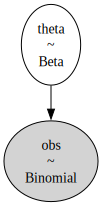

In [7]:
pm.model_to_graphviz(model)

## Esecuzione del campionamento

In precedenza, per il campionamento abbiamo usato la funzione `pm.sample()`.

In [10]:
%%time
with model:
    idata1 = pm.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 30 seconds.


CPU times: user 2.09 s, sys: 90.9 ms, total: 2.18 s
Wall time: 32.2 s


Nel mio computer, l'operazione richiede all'incirca 30 secondi. Ora procederemo con un altro campionamento utilizzando il campionatore JAX. Per implementare questa operazione nel codice, faremo uso dell'istruzione `pm.sampling_jax.sample_numpyro_nuts()`.

In [11]:
with model:
    idata2 = pm.sampling_jax.sample_numpyro_nuts()

Compiling...
Compilation time = 0:00:00.497895
Sampling...
Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]





Running chain 0:   0%|          | 0/2000 [00:01<?, ?it/s]


Running chain 3: 100%|██████████| 2000/2000 [00:01<00:00, 1414.71it/s]
Sampling time = 0:00:01.512206
Transforming variables...
Transformation time = 0:00:00.041246


Si osservi che, nel caso in esame, il processo di campionamento ha impiegato solamente 2 secondi. Sebbene questa accelerazione possa sembrare trascurabile per modelli di semplice costruzione, assume un'importanza significativa quando si tratta di modelli più complessi. In scenari in cui il campionamento può richiedere ore di elaborazione, una diminuzione anche solo del 50% del tempo necessario può avere un impatto considerevole dal punto di vista pratico.

Una volta ottenuto l'oggetto `idata`, questo può essere manipolato come abbiamo fatto in precedenza. Per esempio, per produrre la traccia e la distribuzione a posteriori di $\theta$ chiamiamo `az.plot_trace()`.

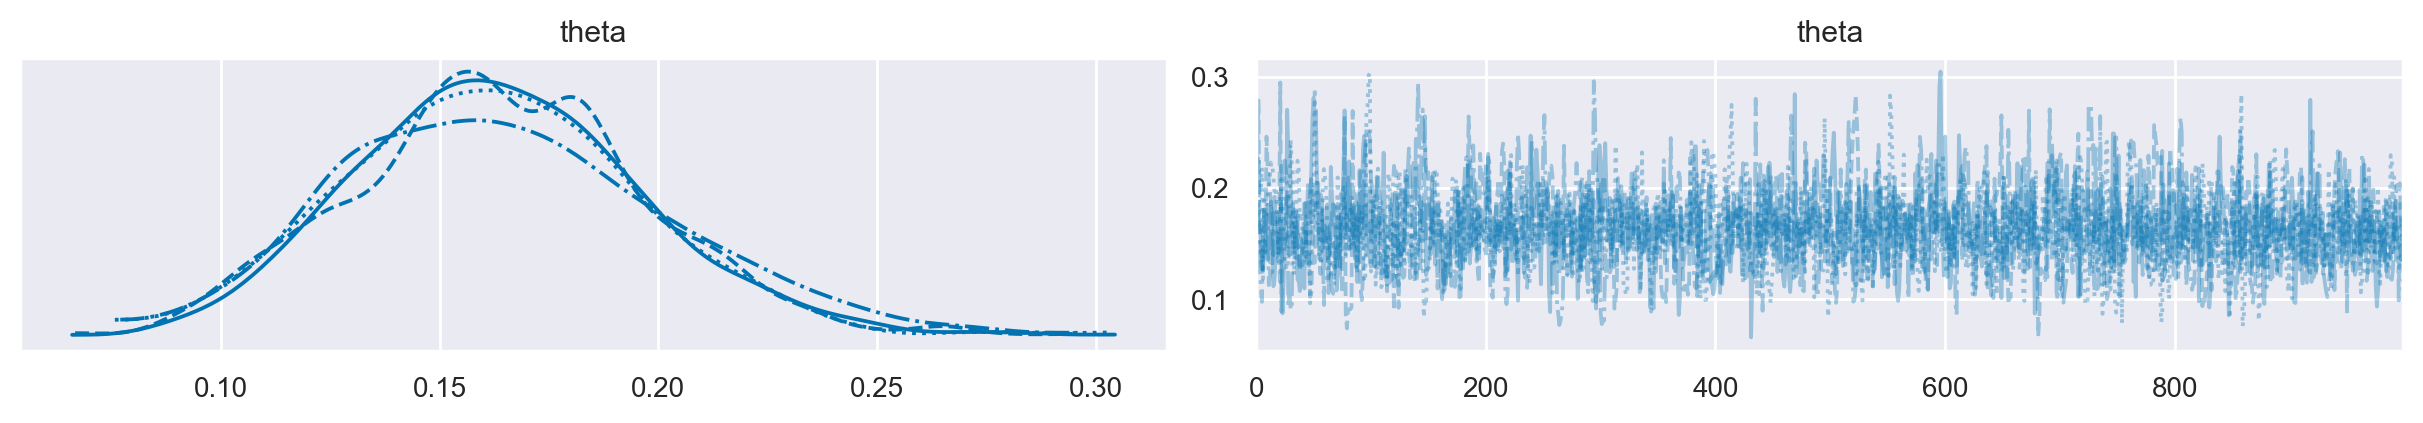

In [14]:
_ = az.plot_trace(idata2)

Per un sommario della distribuzione a posteriori usiamo `az.summary()`.

In [15]:
az.summary(idata2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
theta,0.164,0.035,0.097,0.226,0.001,0.001,1568.0,1720.0,1.0


## Commenti e considerazioni finali 

L'implementazione di JAX rappresenta un notevole progresso nel processo di campionamento di PyMC, offrendo soluzioni più veloci ed efficienti rispetto ai metodi convenzionali. La capacità di accelerare le operazioni di campionamento da parte di JAX consente una maggiore agilità nell'analisi, riducendo i tempi di attesa e agevolando l'esplorazione di modelli più complessi. Inoltre, l'integrazione fluida con PyMC rende questi vantaggi accessibili senza richiedere modifiche al codice esistente.

## Watermark

In [16]:
%load_ext watermark
%watermark -n -u -v -iv -w -p jax -m

Last updated: Mon Feb 26 2024

Python implementation: CPython
Python version       : 3.11.8
IPython version      : 8.22.1

jax: 0.4.23

Compiler    : Clang 16.0.6 
OS          : Darwin
Release     : 23.3.0
Machine     : x86_64
Processor   : i386
CPU cores   : 8
Architecture: 64bit

jax       : 0.4.23
pymc      : 5.10.4
arviz     : 0.17.0
numpy     : 1.26.4
matplotlib: 3.8.3
scipy     : 1.12.0
seaborn   : 0.13.2

Watermark: 2.4.3

